# Milestone 3 — Phase 3: Link Prediction

**CS343 Graph Data Science — Spring 2026**  
**Team:** Muhammad Ammar Maqdoom, Ali Anwar  
**Dataset:** Football Transfers 2017/2018

## ML Problem
Predict potential `SOLD_TO` links between Club nodes ("which clubs are likely to trade with each other?").

## Methodology (course-style)
1. Hold out 10% of `SOLD_TO` edges as test/train positives (`TEST_TRAIN`).
2. Use the remaining 90% as the *feature graph* (`FEATURE_REL`).
3. Sample a similar number of *negative* (non-existent) club pairs as `NEGATIVE_TEST_TRAIN`.
4. Compute classical link-prediction features:
   - `networkDistance` (shortest path)
   - `preferentialAttachment` (degree product)
   - `commonNeighbors`
   - `adamicAdar`
   - `clusteringCoefficient`
5. Train a Random Forest classifier and evaluate.

## Prerequisites
- Run `football_transfers_M2_final_5.cypher` (data loading)
- Run `M3_phase1_feature_engineering.cypher` (must run before this — creates `SOLD_TO` edges)

## 1. Imports and Neo4j Connection

In [1]:
from neo4j import GraphDatabase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

URI = "neo4j://127.0.0.1:7687"
USER = "neo4j"
PASSWORD = "neo4j12345"

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

def run_query(query, params=None):
    with driver.session() as session:
        result = session.run(query, params or {})
        return result.to_df()

print("Connected to Neo4j at", URI)

Connected to Neo4j at neo4j://127.0.0.1:7687


## 2. Reset and Build the Feature Graph

We split the SOLD_TO edges:
- 90% become `FEATURE_REL` (graph used to compute features)
- 10% become `TEST_TRAIN` (positive examples held out for the ML model)

In [2]:
run_query("MATCH ()-[r:FEATURE_REL]->() DELETE r")
run_query("MATCH ()-[r:TEST_TRAIN]->() DELETE r")
run_query("MATCH ()-[r:NEGATIVE_TEST_TRAIN]->() DELETE r")

run_query("""
MATCH (s1:Club)-[:SOLD_TO]->(s2:Club)
WITH s1, s2
WHERE rand() <= 0.9
MERGE (s1)-[:FEATURE_REL]->(s2);
""")

feature_count = run_query("""
MATCH ()-[r:FEATURE_REL]->()
RETURN count(r) AS feature_edges
""")
print("FEATURE_REL count:", int(feature_count["feature_edges"].iloc[0]))

FEATURE_REL count: 16297


In [3]:
test_train_count = run_query("""
MATCH (s1:Club)-[:SOLD_TO]->(s2:Club)
WHERE NOT EXISTS { (s1)-[:FEATURE_REL]->(s2) }
MERGE (s1)-[r:TEST_TRAIN]->(s2)
RETURN count(r) AS test_train_edges
""")
n_pos = int(test_train_count["test_train_edges"].iloc[0])
print("TEST_TRAIN positive edges:", n_pos)

TEST_TRAIN positive edges: 1657


## 3. Sample Negative Club Pairs (no SOLD_TO edge)

We sample roughly the same number of negative pairs as positive, to keep the dataset balanced.

In [4]:
run_query(
    """
MATCH (s1:Club),(s2:Club)
WHERE NOT EXISTS { (s1)-[:SOLD_TO]-(s2) }
  AND elementId(s1) < elementId(s2)
  AND rand() > 0.999
WITH s1, s2
LIMIT $n_pos
MERGE (s1)-[:NEGATIVE_TEST_TRAIN]->(s2);
    """,
    {"n_pos": n_pos},
)

neg_count = run_query("""
MATCH ()-[r:NEGATIVE_TEST_TRAIN]->()
RETURN count(r) AS negative_edges
""")
print("NEGATIVE_TEST_TRAIN edges:", int(neg_count["negative_edges"].iloc[0]))

NEGATIVE_TEST_TRAIN edges: 1657


## 4. Feature 1 — Network Distance (Shortest Path)

For each candidate pair, compute shortest-path length on the FEATURE_REL graph (bounded depth for performance).

In [5]:
run_query("""
MATCH (s1:Club)-[r:TEST_TRAIN|NEGATIVE_TEST_TRAIN]->(s2:Club)
OPTIONAL MATCH p = shortestPath((s1)-[:FEATURE_REL*..6]-(s2))
WITH r, length(p) AS networkDistance
SET r.networkDistance = networkDistance
""")
print("networkDistance computed.")

networkDistance computed.


## 5. Feature 2 — Preferential Attachment

`degree(s1) * degree(s2)` on the FEATURE_REL graph.

In [6]:
run_query("""
MATCH (s1:Club)-[r:TEST_TRAIN|NEGATIVE_TEST_TRAIN]->(s2:Club)
WITH r,
     count{ (s1)-[:FEATURE_REL]-() } AS d1,
     count{ (s2)-[:FEATURE_REL]-() } AS d2
SET r.preferentialAttachment = d1 * d2
""")
print("preferentialAttachment computed.")

preferentialAttachment computed.


## 6. Feature 3 — Common Neighbors

In [7]:
run_query("""
MATCH (s1:Club)-[r:TEST_TRAIN|NEGATIVE_TEST_TRAIN]->(s2:Club)
OPTIONAL MATCH (s1)-[:FEATURE_REL]-(neighbor)-[:FEATURE_REL]-(s2)
WITH r, count(DISTINCT neighbor) AS commonNeighbors
SET r.commonNeighbors = commonNeighbors
""")
print("commonNeighbors computed.")

commonNeighbors computed.


## 7. Feature 4 — Adamic–Adar

In [8]:
run_query("""
MATCH (s1:Club)-[r:TEST_TRAIN|NEGATIVE_TEST_TRAIN]->(s2:Club)
OPTIONAL MATCH (s1)-[:FEATURE_REL]-(neighbor)-[:FEATURE_REL]-(s2)
WITH r, collect(DISTINCT neighbor) AS commonNeighbors
UNWIND commonNeighbors AS cn
WITH r, count{ (cn)-[:FEATURE_REL]-() } AS neighborDegree
WITH r,
     sum(
       CASE WHEN neighborDegree > 1
            THEN 1.0 / log(neighborDegree)
            ELSE 0.0
       END
     ) AS adamicAdar
SET r.adamicAdar = adamicAdar
""")
print("adamicAdar computed.")

adamicAdar computed.


## 8. Feature 5 — Clustering Coefficient of Common Neighbors

In [9]:
run_query("""
MATCH (s1:Club)-[r:TEST_TRAIN|NEGATIVE_TEST_TRAIN]->(s2:Club)
OPTIONAL MATCH (s1)-[:FEATURE_REL]-(neighbor)-[:FEATURE_REL]-(s2)
WITH r,
     collect(DISTINCT neighbor) AS commonNeighbors,
     count(DISTINCT neighbor)   AS commonNeighborCount
OPTIONAL MATCH (x)-[:FEATURE_REL]-(y)
WHERE x IN commonNeighbors AND y IN commonNeighbors
  AND elementId(x) < elementId(y)
WITH r, commonNeighborCount,
     count(DISTINCT [elementId(x), elementId(y)]) AS commonNeighborRels
WITH r,
     CASE WHEN commonNeighborCount < 2 THEN 0
          ELSE toFloat(commonNeighborRels) /
               (commonNeighborCount * (commonNeighborCount - 1) / 2)
     END AS clusteringCoefficient
SET r.clusteringCoefficient = clusteringCoefficient
""")
print("clusteringCoefficient computed.")

clusteringCoefficient computed.


## 9. Fetch Features into a DataFrame

In [10]:
data = run_query("""
MATCH (s1:Club)-[r:TEST_TRAIN|NEGATIVE_TEST_TRAIN]->(s2:Club)
RETURN
    s1.name AS fromClub,
    s2.name AS toClub,
    r.networkDistance        AS networkDistance,
    r.preferentialAttachment AS preferentialAttachment,
    r.commonNeighbors        AS commonNeighbors,
    r.adamicAdar             AS adamicAdar,
    r.clusteringCoefficient  AS clusteringCoefficient,
    CASE WHEN type(r) = 'TEST_TRAIN' THEN 1 ELSE 0 END AS label
""")

print("Rows:", len(data))
print("Class balance:")
print(data["label"].value_counts())
data.head()

Rows: 3314
Class balance:
label
1    1657
0    1657
Name: count, dtype: int64


,fromClub,toClub,networkDistance,preferentialAttachment,commonNeighbors,adamicAdar,clusteringCoefficient,label
0,Nacional,Benfica,2.0,144,1,0.310667,0.0,1
1,E. Frankfurt,Benfica,3.0,128,0,NaN,0.0,1
2,Benfica B,Benfica,3.0,80,0,NaN,0.0,1
3,Watford,RSC Anderlecht,2.0,156,1,0.369269,0.0,1
4,TSG Hoffenheim,SC Freiburg,NaN,0,0,NaN,0.0,1


In [11]:
data.describe()

,networkDistance,preferentialAttachment,commonNeighbors,adamicAdar,clusteringCoefficient,label
count,2544.000000,3314.000000,3314.000000,372.000000,3314.000000,3314.000000
mean,4.087657,48.434218,0.165057,0.593873,0.033856,0.500000
std,1.433471,49.674261,0.527743,0.313286,0.175146,0.500075
min,1.000000,0.000000,0.000000,0.264257,0.000000,0.000000
25%,3.000000,7.000000,0.000000,0.352956,0.000000,0.000000
50%,4.000000,35.000000,0.000000,0.455120,0.000000,0.500000
75%,5.000000,77.000000,0.000000,0.743588,0.000000,1.000000
max,6.000000,360.000000,5.000000,2.056505,1.000000,1.000000


## 10. Handle Missing Values

If two clubs are completely disconnected (no path within depth 6), `networkDistance` is `null`. We replace with a large sentinel value (representing "very far apart"). `adamicAdar` may be NaN when no common neighbors exist — we fill with 0.

In [12]:
data["networkDistance"] = data["networkDistance"].fillna(10)
data["adamicAdar"]      = data["adamicAdar"].fillna(0)
data["commonNeighbors"] = data["commonNeighbors"].fillna(0)
data["preferentialAttachment"] = data["preferentialAttachment"].fillna(0)
data["clusteringCoefficient"] = data["clusteringCoefficient"].fillna(0)
print("Missing values handled.")
data.isna().sum()

Missing values handled.


fromClub                  0
toClub                    0
networkDistance           0
preferentialAttachment    0
commonNeighbors           0
adamicAdar                0
clusteringCoefficient     0
label                     0
dtype: int64

## 11. Train Random Forest

In [13]:
feature_cols = [
    "networkDistance",
    "preferentialAttachment",
    "commonNeighbors",
    "adamicAdar",
    "clusteringCoefficient",
]

X = data[feature_cols]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

              precision    recall  f1-score   support

           0     0.9515    0.9458    0.9486       332
           1     0.9459    0.9517    0.9488       331

    accuracy                         0.9487       663
   macro avg     0.9487    0.9487    0.9487       663
weighted avg     0.9487    0.9487    0.9487       663

Accuracy: 0.9487


## 12. Confusion Matrix

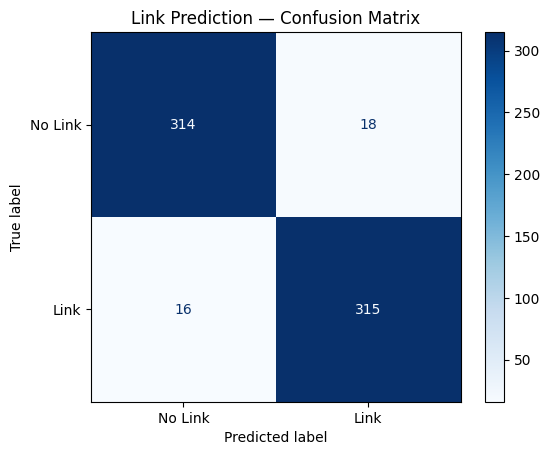

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    display_labels=["No Link", "Link"],
)
plt.title("Link Prediction — Confusion Matrix")
plt.show()

## 13. Feature Importance

                  feature  importance
1  preferentialAttachment    0.589906
0         networkDistance    0.319618
3              adamicAdar    0.047165
2         commonNeighbors    0.042805
4   clusteringCoefficient    0.000505


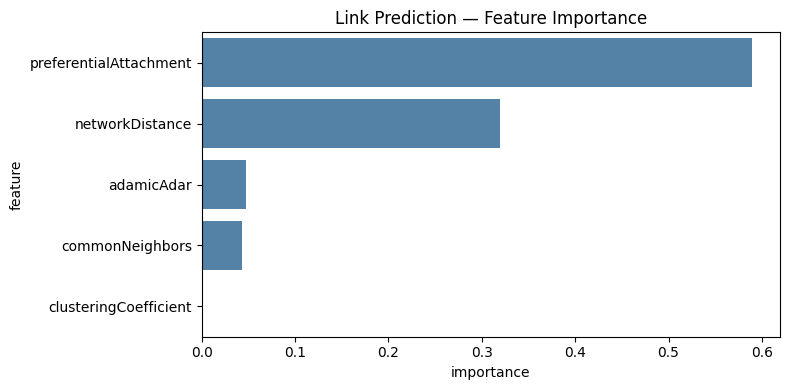

In [15]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances)

plt.figure(figsize=(8, 4))
sns.barplot(data=importances, x="importance", y="feature", color="steelblue")
plt.title("Link Prediction — Feature Importance")
plt.tight_layout()
plt.show()

## 14. Sample Predictions (Test Set)

In [16]:
test_meta = data.loc[X_test.index, ["fromClub", "toClub"]].copy()
test_meta["actual"]    = y_test.values
test_meta["predicted"] = y_pred
test_meta["prob_link"] = rf.predict_proba(X_test)[:, 1]
test_meta = test_meta.sort_values("prob_link", ascending=False)
test_meta.head(20)

,fromClub,toClub,actual,predicted,prob_link
260,Albacete,CD Alcoyano,1,1,1.0
3154,Carpi,Fermana,1,1,1.0
2825,Achilles '29,NEC/FC Oss U19,1,1,1.0
2144,Budoni,Castiadas,1,1,1.0
416,Paradou AC,Ohod Al-Medina,0,1,1.0
241,Cádiz CF,CD Lugo,1,1,1.0
700,Unión Santa Fé,Patronato,1,1,1.0
2907,Drweca NML,Blekitni,1,1,1.0
1579,Chaves,Omonia Nikosia,1,1,1.0
21,Pumas,Rangers,1,1,1.0


## 15. Predict New Likely Links Across All Club Pairs (Top-K Recommendations)

Now use the trained model to score *unseen* club pairs (no SOLD_TO edge) and surface the most likely future links.

In [17]:
candidate_query = """
MATCH (s1:Club),(s2:Club)
WHERE NOT EXISTS { (s1)-[:SOLD_TO]-(s2) }
  AND elementId(s1) < elementId(s2)
  AND s1.buyCount + s1.sellCount >= 5
  AND s2.buyCount + s2.sellCount >= 5
OPTIONAL MATCH p = shortestPath((s1)-[:FEATURE_REL*..4]-(s2))
WITH s1, s2, length(p) AS networkDistance
WHERE networkDistance IS NOT NULL
WITH s1, s2, networkDistance LIMIT 5000
WITH s1, s2, networkDistance,
     count{ (s1)-[:FEATURE_REL]-() } AS d1,
     count{ (s2)-[:FEATURE_REL]-() } AS d2
OPTIONAL MATCH (s1)-[:FEATURE_REL]-(neighbor)-[:FEATURE_REL]-(s2)
WITH s1, s2, networkDistance, d1, d2,
     count(DISTINCT neighbor) AS commonNeighbors,
     collect(DISTINCT neighbor) AS commonNeighborsList
UNWIND (CASE WHEN commonNeighbors = 0 THEN [null] ELSE commonNeighborsList END) AS cn
WITH s1, s2, networkDistance, d1, d2, commonNeighbors, commonNeighborsList,
     CASE WHEN cn IS NULL THEN 0
          ELSE count{ (cn)-[:FEATURE_REL]-() }
     END AS neighborDegree
WITH s1, s2, networkDistance, d1, d2, commonNeighbors, commonNeighborsList,
     sum(CASE WHEN neighborDegree > 1
              THEN 1.0 / log(neighborDegree)
              ELSE 0.0 END) AS adamicAdar
OPTIONAL MATCH (x)-[:FEATURE_REL]-(y)
WHERE x IN commonNeighborsList AND y IN commonNeighborsList
  AND elementId(x) < elementId(y)
WITH s1, s2, networkDistance, d1, d2, commonNeighbors, adamicAdar,
     count(DISTINCT [elementId(x), elementId(y)]) AS commonNeighborRels
WITH s1, s2, networkDistance, d1*d2 AS preferentialAttachment,
     commonNeighbors, adamicAdar,
     CASE WHEN commonNeighbors < 2 THEN 0.0
          ELSE toFloat(commonNeighborRels) /
               (commonNeighbors * (commonNeighbors - 1) / 2)
     END AS clusteringCoefficient
RETURN s1.name AS fromClub,
       s2.name AS toClub,
       networkDistance,
       preferentialAttachment,
       commonNeighbors,
       adamicAdar,
       clusteringCoefficient
"""

candidates = run_query(candidate_query)
print("Candidate pairs scored:", len(candidates))
candidates.head()

Candidate pairs scored: 5000


,fromClub,toClub,networkDistance,preferentialAttachment,commonNeighbors,adamicAdar,clusteringCoefficient
0,Monaco,AS Roma,2,592,4,1.363974,0.333333
1,Monaco,Benfica,2,256,2,0.679784,1.000000
2,AS Roma,Benfica,2,592,3,1.040458,0.333333
3,Monaco,FC Porto,3,224,0,0.000000,0.000000
4,AS Roma,FC Porto,3,518,0,0.000000,0.000000


In [18]:
if len(candidates) > 0:
    candidates["networkDistance"] = candidates["networkDistance"].fillna(10)
    candidates["adamicAdar"]      = candidates["adamicAdar"].fillna(0)
    candidates["commonNeighbors"] = candidates["commonNeighbors"].fillna(0)
    candidates["preferentialAttachment"] = candidates["preferentialAttachment"].fillna(0)
    candidates["clusteringCoefficient"]  = candidates["clusteringCoefficient"].fillna(0)

    candidates["prob_link"] = rf.predict_proba(candidates[feature_cols])[:, 1]

    top_predictions = (
        candidates.sort_values("prob_link", ascending=False)
                  .head(30)
                  .reset_index(drop=True)
    )
    top_predictions

In [19]:
driver.close()
print("Phase 3 complete.")

Phase 3 complete.
